# Laboratorio 3.6: Cuaderno del estudiante

## Información general

Este laboratorio es una continuación de los laboratorios guiados del Módulo 3.

En este laboratorio, evaluará el modelo que entrenó en los módulos anteriores. También calculará métricas basadas en los resultados de los datos de prueba.


## Presentación de la situación empresarial

Trabaja para un proveedor de atención médica y desea mejorar la detección de anomalías en los pacientes de ortopedia. 

Se le asignó la tarea de resolver este problema con el uso de machine learning (ML). Tiene acceso a un conjunto de datos que contiene seis funciones biomecánicas y un objetivo de *normal* o *anormal*. Puede usar este conjunto de datos para entrenar un modelo de ML para predecir si un paciente tendrá una anomalía.


## Acerca de este conjunto de datos

Este conjunto de datos biomédicos fue creado por el Dr. Henrique da Mota durante un periodo de residencia médica en el Group of Applied Research in Orthopaedics (GARO) del Centre Médico-Chirurgical de Réadaptation des Massues, Lyon, Francia. Los datos se organizaron en dos tareas de clasificación diferentes pero que se relacionan. 

La primera tarea consiste en clasificar pacientes como pertenecientes a una de tres categorías: 

- *Normal* (100 pacientes)
- *Hernia de disco* (60 pacientes)
- *Espondilolistesis* (150 pacientes)

Para la segunda tarea, las categorías *hernia de disco* y *espondilolistesis* se fusionaron en una sola categoría que se denomina *anormal*. Por ende, la segunda tarea consiste en clasificar a los pacientes como pertenecientes a una de dos categorías: *normal* (100 pacientes) o *anormal* (210 pacientes).


## Información de atributos

Cada paciente está representado en el conjunto de datos por seis atributos biomecánicos que se derivan de la forma y la orientación de la pelvis y la columna lumbar (en este orden): 

- Pelvic incidence (Incidencia pélvica)
- Pelvic tilt (Inclinación pélvica)
- Lumbar lordosis angle (Ángulo de lordosis lumbar)
- Sacral slope (Pendiente sacra)
- Pelvic radius (Radio pélvico)
- Grade of spondylolisthesis (Grado de espondilolistesis)

Se usa la siguiente convención para las etiquetas de clase: 
- DH (hernia de disco)
- SL (espondilolistesis)
- NO (normal) 
- AB (anormal)

Para obtener más información sobre este conjunto de datos, consulte la [página web del conjunto de datos de la columna vertebral](http://archive.ics.uci.edu/ml/datasets/Vertebral+Column).


## Atribuciones del conjunto de datos

Este conjunto de datos se obtuvo de:
Dua, D. y Graff, C. (2019). Repositorio de Machine Learning de UCI (http://archive.ics.uci.edu/ml). Irvine, CA: Universidad de California, School of Information and Computer Science.


# Configuración del laboratorio

Debido a que esta solución se divide en varios laboratorios en el módulo, debe ejecutar las siguientes celdas para poder cargar los datos y entrenar el modelo que se implementará.

**Nota:** La configuración puede tardar hasta 5 minutos en completarse.

## Importación de los datos y entrenamiento del modelo

Ejecute las siguientes celdas para importar los datos y dejarlos listos para utilizarse. 

**Nota:** Las siguientes celdas representan los pasos clave de los laboratorios anteriores.


In [1]:
bucket='c140299a3602575l8528436t1w991115526873-labbucket-fu4jtt9ydphy'

In [2]:
import warnings, requests, zipfile, io
warnings.simplefilter('ignore')
import pandas as pd
from scipy.io import arff

import os
import boto3
import sagemaker
from sagemaker.image_uris import retrieve
from sklearn.model_selection import train_test_split

[11/25/24 18:49:40] INFO     Found credentials from IAM Role:                                   ]8;id=109430;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=449918;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/botocore/credentials.py#1075\1075]8;;\
                             BaseNotebookInstanceEc2InstanceRole                                                   

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/ec2-user/.config/sagemaker/config.yaml


In [ ]:
# URL del archivo .zip que contiene los datos
f_zip = 'http://archive.ics.uci.edu/ml/machine-learning-databases/00212/vertebral_column_data.zip'

# Descargar el archivo .zip desde la URL usando la librería requests
r = requests.get(f_zip, stream=True)

# Leer el contenido del archivo descargado como un archivo zip en memoria
Vertebral_zip = zipfile.ZipFile(io.BytesIO(r.content))

# Extraer todos los archivos del zip en el directorio actual
Vertebral_zip.extractall()

# Cargar el archivo .arff extraído y convertirlo en un DataFrame de pandas
data = arff.loadarff('column_2C_weka.arff')
df = pd.DataFrame(data[0])

# Mapear la columna 'class' para que los valores sean 1 (Abnormal) y 0 (Normal)
class_mapper = {b'Abnormal':1,b'Normal':0}
df['class'] = df['class'].replace(class_mapper)

# Reordenar las columnas para que 'class' sea la primera columna
cols = df.columns.tolist()
cols = cols[-1:] + cols[:-1]
df = df[cols]

# Dividir el DataFrame en entrenamiento (80%) y prueba + validación (20%)
train, test_and_validate = train_test_split(df, test_size=0.2, random_state=42, stratify=df['class'])

# Dividir el conjunto de prueba y validación en mitades iguales (10% cada uno)
test, validate = train_test_split(test_and_validate, test_size=0.5, random_state=42, stratify=test_and_validate['class'])

# Prefijo para las rutas en S3
prefix = 'lab3'

# Nombres de los archivos CSV que se subirán a S3
train_file = 'vertebral_train.csv'
test_file = 'vertebral_test.csv'
validate_file = 'vertebral_validate.csv'

# Crear una conexión con S3 usando boto3
s3_resource = boto3.Session().resource('s3')

# Función para subir un DataFrame a S3 como archivo CSV
def upload_s3_csv(filename, folder, dataframe):
    csv_buffer = io.StringIO()  # Crear un buffer en memoria para guardar el archivo CSV
    dataframe.to_csv(csv_buffer, header=False, index=False)  # Guardar el DataFrame en el buffer
    # Subir el contenido del buffer a S3
    s3_resource.Bucket(bucket).Object(os.path.join(prefix, folder, filename)).put(Body=csv_buffer.getvalue())

# Subir los conjuntos de datos a S3
upload_s3_csv(train_file, 'train', train)       # Conjunto de entrenamiento
upload_s3_csv(test_file, 'test', test)         # Conjunto de prueba
upload_s3_csv(validate_file, 'validate', validate)  # Conjunto de validación

# Obtener la imagen del contenedor de XGBoost de SageMaker
container = retrieve('xgboost', boto3.Session().region_name, '1.0-1')

# Definir los hiperparámetros del modelo XGBoost
hyperparams = {
    "num_round": "42",            # Número de rondas de entrenamiento
    "eval_metric": "auc",         # Métrica de evaluación (área bajo la curva)
    "objective": "binary:logistic"  # Objetivo del modelo: clasificación binaria
}

# Ruta en S3 donde se guardarán los resultados del modelo
s3_output_location = "s3://{}/{}/output/".format(bucket, prefix)

# Configurar el modelo XGBoost en SageMaker
xgb_model = sagemaker.estimator.Estimator(
    container,                                      # Contenedor de XGBoost
    sagemaker.get_execution_role(),                # Rol de ejecución en AWS
    instance_count=1,                              # Número de instancias de entrenamiento
    instance_type='ml.m4.xlarge',                  # Tipo de instancia para el entrenamiento
    output_path=s3_output_location,               # Ruta para los resultados
    hyperparameters=hyperparams,                  # Hiperparámetros
    sagemaker_session=sagemaker.Session()         # Sesión de SageMaker
)

# Crear los canales de datos de entrenamiento y validación para SageMaker
train_channel = sagemaker.inputs.TrainingInput(
    "s3://{}/{}/train/".format(bucket, prefix, train_file),
    content_type='text/csv'  # Especificar que los datos están en formato CSV
)

validate_channel = sagemaker.inputs.TrainingInput(
    "s3://{}/{}/validate/".format(bucket, prefix, validate_file),
    content_type='text/csv'  # Especificar que los datos están en formato CSV
)

# Combinar los canales en un diccionario
data_channels = {'train': train_channel, 'validation': validate_channel}

# Entrenar el modelo en SageMaker
xgb_model.fit(inputs=data_channels, logs=False)

# Seleccionar las columnas de características (sin incluir la clase) para predicciones en lote
batch_X = test.iloc[:, 1:]

# Guardar los datos de prueba en un archivo CSV para subirlo a S3
batch_X_file = 'batch-in.csv'
upload_s3_csv(batch_X_file, 'batch-in', batch_X)

# Configurar la salida y entrada del transformador (predicciones en lote)
batch_output = "s3://{}/{}/batch-out/".format(bucket, prefix)
batch_input = "s3://{}/{}/batch-in/{}".format(bucket, prefix, batch_X_file)

# Configurar el transformador para ejecutar predicciones en lote
xgb_transformer = xgb_model.transformer(
    instance_count=1,                # Número de instancias
    instance_type='ml.m4.xlarge',    # Tipo de instancia
    strategy='MultiRecord',          # Estrategia de procesamiento en lote
    assemble_with='Line',            # Cómo combinar las líneas de salida
    output_path=batch_output         # Ruta de salida en S3
)

# Ejecutar las predicciones en lote
xgb_transformer.transform(
    data=batch_input,                # Archivo de entrada en S3
    data_type='S3Prefix',            # Tipo de datos
    content_type='text/csv',         # Formato del archivo
    split_type='Line'                # Dividir por líneas
)

# Esperar a que el trabajo de predicción termine
xgb_transformer.wait()

# Descargar el archivo de predicciones desde S3
s3 = boto3.client('s3')
obj = s3.get_object(Bucket=bucket, Key="{}/batch-out/{}".format(prefix, 'batch-in.csv.out'))

# Cargar las predicciones en un DataFrame de pandas
target_predicted = pd.read_csv(io.BytesIO(obj['Body'].read()), names=['class'])


[11/25/24 19:32:12] INFO     Found credentials from IAM Role:                                   ]8;id=661844;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=128515;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/botocore/credentials.py#1075\1075]8;;\
                             BaseNotebookInstanceEc2InstanceRole                                                   

                    INFO     Defaulting to only available Python version: py3                     ]8;id=560446;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/image_uris.py\image_uris.py]8;;\:]8;id=319306;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/image_uris.py#603\603]8;;\

                    INFO     Defaulting to only supported image scope: cpu.                       ]8;id=155740;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/image_uris.py\image_uris.py]8;;\:]8;id=773555;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/image_uris.py#527\527]8;;\

[11/25/24 19:32:13] INFO     Creating training-job with name:                                       ]8;id=242783;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/session.py\session.py]8;;\:]8;id=839376;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/session.py#1042\1042]8;;\
                             sagemaker-xgboost-2024-11-25-19-32-13-034                                             


2024-11-25 19:32:14 Starting - Starting the training job..
2024-11-25 19:32:29 Starting - Preparing the instances for training....
2024-11-25 19:32:55 Downloading - Downloading input data.....
2024-11-25 19:33:25 Downloading - Downloading the training image..........
2024-11-25 19:34:21 Training - Training image download completed. Training in progress...
2024-11-25 19:34:37 Uploading - Uploading generated training model..
2024-11-25 19:34:50 Completed - Training job completed


[11/25/24 19:34:55] INFO     Creating model with name: sagemaker-xgboost-2024-11-25-19-34-55-164    ]8;id=909969;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/session.py\session.py]8;;\:]8;id=234423;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/session.py#4025\4025]8;;\

                    INFO     Creating transform job with name:                                      ]8;id=148495;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/session.py\session.py]8;;\:]8;id=656442;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/session.py#3882\3882]8;;\
                             sagemaker-xgboost-2024-11-25-19-34-55-778                                             

...................

# Paso 1: exploración de los resultados

El resultado del modelo será una probabilidad. Primero debe convertir esa probabilidad en una de las dos clases, *0* o *1*. Para ello, puede crear una función para realizar la conversión. Tenga en cuenta el uso del umbral en la función.

In [18]:
# Definir una función para convertir valores continuos en valores binarios
def binary_convert(x):
    threshold = 0.3  # Umbral para la clasificación binaria
    if x > threshold:  # Si el valor es mayor al umbral, se clasifica como 1
        return 1
    else:              # Si el valor es menor o igual al umbral, se clasifica como 0
        return 0

# Aplicar la función 'binary_convert' a la columna 'class' del DataFrame 'target_predicted'
# Esto convierte las predicciones continuas (probabilidades) en clases binarias (0 o 1)
target_predicted_binary = target_predicted['class'].apply(binary_convert)

# Imprimir las primeras 5 filas de las predicciones binarias
print(target_predicted_binary.head(5))

# Mostrar las primeras 5 filas del conjunto de datos original de prueba
# Esto permite comparar las predicciones binarias con los datos reales
test.head(5)


0    1
1    1
2    1
3    1
4    1
Name: class, dtype: int64


,class,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis
136,1,88.024499,39.844669,81.774473,48.179830,116.601538,56.766083
230,0,65.611802,23.137919,62.582179,42.473883,124.128001,-4.083298
134,1,52.204693,17.212673,78.094969,34.992020,136.972517,54.939134
130,1,50.066786,9.120340,32.168463,40.946446,99.712453,26.766697
47,1,41.352504,16.577364,30.706191,24.775141,113.266675,-4.497958


De acuerdo con estos resultados, puede ver que el modelo inicial podría no ser tan bueno. Es difícil diferenciar comparando unos cuantos valores.

A continuación, generará algunas métricas para ver cómo es el rendimiento del modelo.


# Paso 2: creación de la matriz de confusión

Una *matriz de confusión* es una de las maneras clave de medir el rendimiento de un modelo de clasificación. Es una tabla que mapea las predicciones correctas e incorrectas. Después de calcular una matriz de confusión para su modelo, puede generar varias otras estadísticas. Sin embargo, primero creará solo la matriz de confusión.

Para crear una matriz de confusión, necesita los valores objetivo de sus datos de prueba *y* el valor previsto. 

Obtenga los objetivos desde el DataFrame de prueba.

In [19]:
# Extraer la primera columna del DataFrame 'test' (que corresponde a las etiquetas reales)
test_labels = test.iloc[:, 0]

# Mostrar las primeras 5 filas de las etiquetas de prueba
test_labels.head()


136    1
230    0
134    1
130    1
47     1
Name: class, dtype: int64

Ahora puede usar la biblioteca *scikit-learn*, que contiene una función para crear una matriz de confusión.

In [20]:
# Importar la función confusion_matrix de sklearn para calcular la matriz de confusión
from sklearn.metrics import confusion_matrix

# Calcular la matriz de confusión entre las etiquetas reales y las predicciones binarias
matrix = confusion_matrix(test_labels, target_predicted_binary)

# Crear un DataFrame con la matriz de confusión para facilitar su visualización
# Las filas representan las clases reales (índice) y las columnas las predicciones
df_confusion = pd.DataFrame(matrix, index=['Normal', 'Abnormal'], columns=['Normal', 'Abnormal'])

# Mostrar el DataFrame de la matriz de confusión
df_confusion


,Normal,Abnormal
Normal,7,3
Abnormal,3,18


Sus resultados variarán, pero debe obtener resultados similares a este ejemplo:

_ | Normal | Abnormal
---------- | ----: | ----:
Normal | 7 | 3
Abnormal | 3 | 18



La tabla anterior muestra que el modelo predijo correctamente los valores *7 Normal* y *18 Abnormal*. Sin embargo, predijo incorrectamente los valores *3 Normal* y *3 Abnormal*. 

Con las bibliotecas de Python *seaborn* y *matplotlib*, puede trazar estos valores en un gráfico para hacerlos más fáciles de leer.

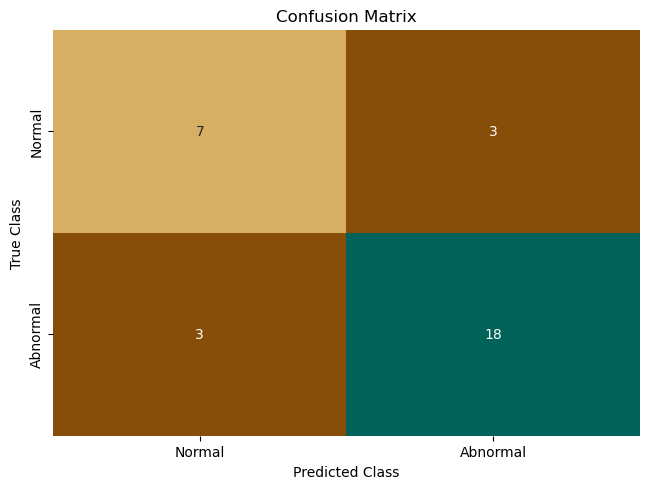

In [21]:
# Importar las librerías necesarias para visualización: seaborn y matplotlib
import seaborn as sns
import matplotlib.pyplot as plt

# Definir un mapa de colores usando la paleta "BrBG" de seaborn
colormap = sns.color_palette("BrBG", 10)

# Crear un mapa de calor a partir del DataFrame de la matriz de confusión
# 'annot=True' añade los valores dentro de las celdas, y 'cbar=None' elimina la barra de color
sns.heatmap(df_confusion, annot=True, cbar=None, cmap=colormap)

# Añadir un título al gráfico
plt.title("Confusion Matrix")

# Ajustar automáticamente los márgenes para una mejor presentación
plt.tight_layout()

# Etiquetar el eje Y como "True Class" (clase real)
plt.ylabel("True Class")

# Etiquetar el eje X como "Predicted Class" (clase predicha)
plt.xlabel("Predicted Class")

# Mostrar el gráfico
plt.show()


**Sugerencia:** Si el gráfico no se muestra la primera vez, intente ejecutar la celda de nuevo.

Si estos resultados son suficientemente buenos para su aplicación, el modelo podría ser suficientemente bueno. Sin embargo, debido a que predecir incorrectamente los valores *Normal* tiene consecuencias, es decir, no se encontró ninguna anomalía cuando de hecho había una, el foco debe estar en reducir este resultado.

# Paso 3: cálculo de las estadísticas de rendimiento

Si desea comparar este modelo con el siguiente modelo que cree, necesita algunas métricas que pueda registrar. Para un problema de clasificación binaria, se pueden usar los datos de la matriz de confusión para calcular diversas métricas.

Para comenzar, extraiga los valores de las celdas de la matriz de confusión como variables.

In [22]:
# Importar métricas necesarias para el análisis del modelo: roc_auc_score, roc_curve y auc
from sklearn.metrics import roc_auc_score, roc_curve, auc

# Extraer los valores de la matriz de confusión para True Negative (TN), False Positive (FP),
# False Negative (FN) y True Positive (TP) con la función .ravel()
TN, FP, FN, TP = confusion_matrix(test_labels, target_predicted_binary).ravel()

# Imprimir cada métrica obtenida de la matriz de confusión
print(f"True Negative (TN) : {TN}")  # Predicciones correctas para la clase 'Normal'
print(f"False Positive (FP): {FP}")  # Predicciones incorrectas donde 'Normal' fue clasificado como 'Abnormal'
print(f"False Negative (FN): {FN}")  # Predicciones incorrectas donde 'Abnormal' fue clasificado como 'Normal'
print(f"True Positive (TP) : {TP}")  # Predicciones correctas para la clase 'Abnormal'


True Negative (TN) : 7
False Positive (FP): 3
False Negative (FN): 3
True Positive (TP) : 18


Ahora puede calcular algunas estadísticas.


### Sensibilidad

*Sensibilidad* también se conoce como *tasa de aciertos*, *exhaustividad* o *tasa de positivos reales (true positive rate, TPR)*. Mide la proporción de los positivos reales que se identificaron correctamente.

En este ejemplo, la sensibilidad es *la probabilidad de detectar una anomalía para pacientes con una anomalía*.

In [23]:
# Calcular la sensibilidad (True Positive Rate, TPR)
# Fórmula: Sensitivity = TP / (TP + FN), donde:
# TP = Verdaderos positivos, FN = Falsos negativos
Sensitivity  = float(TP) / (TP + FN) * 100

# Imprimir la sensibilidad como porcentaje
print(f"Sensitivity or TPR: {Sensitivity}%")

# Explicación interpretativa del valor de la sensibilidad
# Indica la probabilidad de que el modelo detecte correctamente a los pacientes con una anomalía
print(f"There is a {Sensitivity}% chance of detecting patients with an abnormality have an abnormality")


Sensitivity or TPR: 85.71428571428571%
There is a 85.71428571428571% chance of detecting patients with an abnormality have an abnormality


**Pregunta:** ¿La sensibilidad es suficientemente buena para esta situación?


### Especificidad

La siguiente estadística es *especificidad*, que también se conoce como *negativo real*. Mide la proporción de los negativos reales que se identificaron correctamente.

En este ejemplo, la especificidad es *la probabilidad de detectar normal para pacientes que son normales*.

In [24]:
# Calcular la especificidad (True Negative Rate, TNR)
# Fórmula: Specificity = TN / (TN + FP), donde:
# TN = Verdaderos negativos, FP = Falsos positivos
Specificity = float(TN) / (TN + FP) * 100

# Imprimir la especificidad como porcentaje
print(f"Specificity or TNR: {Specificity}%")

# Explicación interpretativa del valor de la especificidad
# Indica la probabilidad de que el modelo detecte correctamente a los pacientes normales
print(f"There is a {Specificity}% chance of detecting normal patients are normal.")


Specificity or TNR: 70.0%
There is a 70.0% chance of detecting normal patients are normal.


**Pregunta:** ¿La especificidad es demasiado baja, es la medida exacta o es de.masiado alta? ¿Qué valor le gustaría que se viera aquí, considerando la situación?



### Valores predictivos positivos y negativos

La *precisión*, o el *valor predictivo positivo*, es la proporción de resultados positivos.

En este ejemplo, el valor predictivo positivo es *la probabilidad de que los sujetos con un resultado positivo en el examen de detección realmente tengan una anomalía*.

In [25]:
# Calcular la precisión (Precision o Positive Predictive Value, PPV)
# Fórmula: Precision = TP / (TP + FP), donde:
# TP = Verdaderos positivos, FP = Falsos positivos
Precision = float(TP) / (TP + FP) * 100

# Imprimir la precisión como porcentaje
print(f"Precision: {Precision}%")

# Explicación interpretativa del valor de la precisión
# Indica la probabilidad de que, si el modelo predice que una persona tiene una anomalía, esta predicción sea correcta
print(f"You have an abnormality, and the probability that is correct is {Precision}%")


Precision: 85.71428571428571%
You have an abnormality, and the probability that is correct is 85.71428571428571%


El *valor predictivo negativo*, es la proporción de resultados negativos.

En este ejemplo, el valor predictivo negativo es *la probabilidad de que los sujetos con un resultado negativo en el examen de detección realmente tengan una anomalía*.

In [26]:
# Calcular el valor predictivo negativo (Negative Predictive Value, NPV)
# Fórmula: NPV = TN / (TN + FN), donde:
# TN = Verdaderos negativos, FN = Falsos negativos
NPV = float(TN) / (TN + FN) * 100

# Imprimir el valor predictivo negativo como porcentaje
print(f"Negative Predictive Value: {NPV}%")

# Explicación interpretativa del valor del NPV
# Indica la probabilidad de que, si el modelo predice que una persona no tiene una anomalía, esa predicción sea correcta
print(f"You don't have an abnormality, but there is a {NPV}% chance that is incorrect")


Negative Predictive Value: 70.0%
You don't have an abnormality, but there is a 70.0% chance that is incorrect


Piense en el impacto de estos valores. Si usted fuera un paciente, ¿cuánto debería preocuparse si el resultado de la prueba de una anomalía fuera positivo? Por el contrario, ¿cuánto debería tranquilizarlo si el resultado fuera negativo?


### Tasa de falsos positivos

La *tasa de falsos positivos (false positive rate, FPR)* es la probabilidad de que se genere una falsa alarma *se dará un resultado positivo cuando el valor real es negativo*. 

In [27]:
# Calcular la tasa de falsos positivos (Fall Out o False Positive Rate, FPR)
# Fórmula: FPR = FP / (FP + TN), donde:
# FP = Falsos positivos, TN = Verdaderos negativos
FPR = float(FP) / (FP + TN) * 100

# Imprimir la tasa de falsos positivos como porcentaje
print(f"False Positive Rate: {FPR}%")

# Explicación interpretativa del valor de la FPR
# Indica la probabilidad de que el modelo clasifique incorrectamente como positivo un caso que es realmente negativo
print(f"There is a {FPR}% chance that this positive result is incorrect.")


False Positive Rate: 30.0%
There is a 30.0% chance that this positive result is incorrect.


### Tasa de falsos negativos

La *tasa de falsos negativos* o *tasa de error* es *la probabilidad de que la prueba omita un positivo real*.

In [28]:
# Calcular la tasa de falsos negativos (False Negative Rate, FNR)
# Fórmula: FNR = FN / (TP + FN), donde:
# FN = Falsos negativos, TP = Verdaderos positivos
FNR = float(FN) / (TP + FN) * 100

# Imprimir la tasa de falsos negativos como porcentaje
print(f"False Negative Rate: {FNR}%")

# Explicación interpretativa del valor de la FNR
# Indica la probabilidad de que el modelo clasifique incorrectamente como negativo un caso que es realmente positivo
print(f"There is a {FNR}% chance that this negative result is incorrect.")


False Negative Rate: 14.285714285714285%
There is a 14.285714285714285% chance that this negative result is incorrect.


### Tasa de falsos descubrimientos

En este ejemplo, la *tasa de falsos descubrimientos* es *la probabilidad de predecir una anomalía cuando el paciente no tiene una*.

In [29]:
# Calcular la tasa de falsos descubrimientos (False Discovery Rate, FDR)
# Fórmula: FDR = FP / (TP + FP), donde:
# FP = Falsos positivos, TP = Verdaderos positivos
FDR = float(FP) / (TP + FP) * 100

# Imprimir la tasa de falsos descubrimientos como porcentaje
print(f"False Discovery Rate: {FDR}%")

# Explicación interpretativa del valor de la FDR
# Indica la probabilidad de que, si el modelo predice una anomalía, esta predicción sea incorrecta
print(f"You have an abnormality, but there is a {FDR}% chance this is incorrect.")


False Discovery Rate: 14.285714285714285%
You have an abnormality, but there is a 14.285714285714285% chance this is incorrect.


### Exactitud general

¿Cuál es el grado de exactitud de su modelo?

In [30]:
# Calcular la exactitud general (Overall Accuracy, ACC)
# Fórmula: ACC = (TP + TN) / (TP + FP + FN + TN), donde:
# TP = Verdaderos positivos, TN = Verdaderos negativos
# FP = Falsos positivos, FN = Falsos negativos
ACC = float(TP + TN) / (TP + FP + FN + TN) * 100

# Imprimir la exactitud general como porcentaje
print(f"Accuracy: {ACC}%")


Accuracy: 80.64516129032258%


En resumen, calculó las siguientes métricas a partir de su modelo:

In [31]:
# Imprimir todas las métricas calculadas con sus descripciones
print(f"Sensitivity or TPR: {Sensitivity}%")  # Tasa de verdaderos positivos
print(f"Specificity or TNR: {Specificity}%")  # Tasa de verdaderos negativos
print(f"Precision: {Precision}%")  # Valor predictivo positivo
print(f"Negative Predictive Value: {NPV}%")  # Valor predictivo negativo
print(f"False Positive Rate: {FPR}%")  # Tasa de falsos positivos
print(f"False Negative Rate: {FNR}%")  # Tasa de falsos negativos
print(f"False Discovery Rate: {FDR}%")  # Tasa de falsos descubrimientos
print(f"Accuracy: {ACC}%")  # Exactitud general del modelo


Sensitivity or TPR: 85.71428571428571%
Specificity or TNR: 70.0%
Precision: 85.71428571428571%
Negative Predictive Value: 70.0%
False Positive Rate: 30.0%
False Negative Rate: 14.285714285714285%
False Discovery Rate: 14.285714285714285%
Accuracy: 80.64516129032258%


**Tarea de desafío:** registre los valores anteriores, luego, vuelva al paso 1 y cambie el valor que se usó para el umbral. Los valores que debe probar son *.25* y *.75*. 

¿Esos valores marcaron una diferencia?

# Paso 4: cálculo de la curva AUC-ROC

La biblioteca scikit-learn tiene funciones que le permiten calcular la *el área bajo la curva de la característica operativa del receptor (AUC-ROC)*.

- La ROC es una curva de probabilidad.
- El AUC le indica qué tan bien el modelo puede distinguir entre clases. 

El AUC se puede calcular. Como verá en el siguiente laboratorio, se puede usar para medir el rendimiento del modelo. 

En este ejemplo, cuanto más alta es el AUC, mejor es el modelo para distinguir entre pacientes anormales y normales.

Dependiendo del valor que establezca para el umbral, el AUC puede cambiar. Puede trazar el AUC con la probabilidad en lugar de con la clase convertida.


In [32]:
# Extraer las etiquetas reales (test_labels) de la primera columna del conjunto de prueba
test_labels = test.iloc[:, 0]

# Calcular el Área Bajo la Curva (AUC) para el conjunto de validación
# roc_auc_score evalúa la calidad del modelo en términos de probabilidad
print("Validation AUC", roc_auc_score(test_labels, target_predicted))


Validation AUC 0.8904761904761904


Normalmente, la curva ROC se traza con la TPR en comparación con la FPR, donde la TPR se ubica en el eje y mientras que la FPR está en el eje x.

Scikit-learn tiene la función **roc_curve** para ayudar con la generación de esos valores para trazar.

╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:39                                                                                   │
│                                                                                                  │
│   36 ax2.set_ylabel('Threshold', color='r')                                                      │
│   37                                                                                             │
│   38 # Configurar los límites del segundo eje Y para mostrar los umbrales en orden descendent    │
│ ❱ 39 ax2.set_ylim([thresholds[-1], thresholds[0]])                                               │
│   40                                                                                             │
│   41 # Ajustar los límites del eje X del gráfico secundario para que coincidan con los de la     │
│   42 ax2.set_xlim([fpr[0], fpr[-1]])                                                             │
│                                                                                                  │
│ /home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/matplotlib/axes/_base.py:3973 │
│ in set_ylim                                                                                      │
│                                                                                                  │
│   3970 │   │   │   if top is not None:                                                           │
│   3971 │   │   │   │   raise TypeError("Cannot pass both 'top' and 'ymax'")                      │
│   3972 │   │   │   top = ymax                                                                    │
│ ❱ 3973 │   │   return self.yaxis._set_lim(bottom, top, emit=emit, auto=auto)                     │
│   3974 │                                                                                         │
│   3975 │   get_yscale = _axis_method_wrapper("yaxis", "get_scale")                               │
│   3976 │   set_yscale = _axis_method_wrapper("yaxis", "_set_axes_scale")                         │
│                                                                                                  │
│ /home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/matplotlib/axis.py:1237 in    │
│ _set_lim                                                                                         │
│                                                                                                  │
│   1234 │   │                                                                                     │
│   1235 │   │   self.axes._process_unit_info([(name, (v0, v1))], convert=False)                   │
│   1236 │   │   v0 = self.axes._validate_converted_limits(v0, self.convert_units)                 │
│ ❱ 1237 │   │   v1 = self.axes._validate_converted_limits(v1, self.convert_units)                 │
│   1238 │   │                                                                                     │
│   1239 │   │   if v0 is None or v1 is None:                                                      │
│   1240 │   │   │   # Axes init calls set_xlim(0, 1) before get_xlim() can be called,             │
│                                                                                                  │
│ /home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/matplotlib/axes/_base.py:3660 │
│ in _validate_converted_limits                                                                    │
│                                                                                                  │
│   3657 │   │   │   │   converted_limit = converted_limit.squeeze()                               │
│   3658 │   │   │   if (isinstance(converted_limit, Real)                                         │
│   3659 │   │   │   │   │   and not np.isfinite(converted_limit)):                                │
│ ❱ 3660 │   │   │   │   raise ValueError("Axis limits cannot

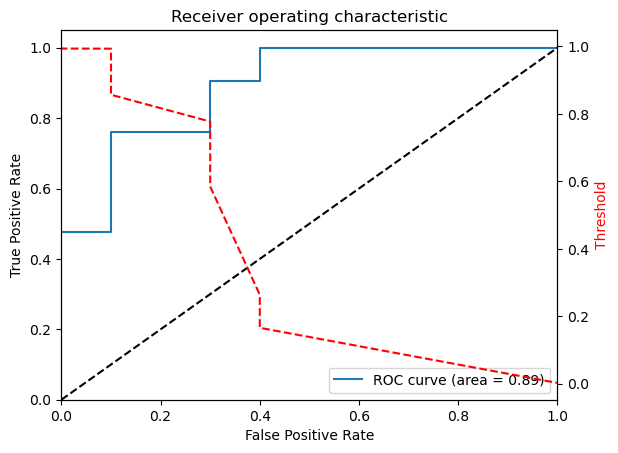

In [33]:
# Calcular la curva ROC (Receiver Operating Characteristic)
# roc_curve devuelve las tasas de falsos positivos (fpr), verdaderos positivos (tpr), y los umbrales de decisión
fpr, tpr, thresholds = roc_curve(test_labels, target_predicted)

# Calcular el área bajo la curva (AUC) para evaluar la calidad de la clasificación
roc_auc = auc(fpr, tpr)

# Crear una nueva figura para el gráfico
plt.figure()

# Graficar la curva ROC con su AUC
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % (roc_auc))

# Añadir una línea diagonal punteada que representa un modelo aleatorio
plt.plot([0, 1], [0, 1], 'k--')

# Configurar los límites del eje X y Y
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

# Etiquetas y título del gráfico
plt.xlabel('False Positive Rate')  # Tasa de falsos positivos
plt.ylabel('True Positive Rate')  # Tasa de verdaderos positivos
plt.title('Receiver operating characteristic')  # Título del gráfico

# Añadir una leyenda en la esquina inferior derecha
plt.legend(loc="lower right")

# Crear un segundo eje Y para mostrar los umbrales de decisión
ax2 = plt.gca().twinx()

# Graficar los umbrales en función de la tasa de falsos positivos
ax2.plot(fpr, thresholds, markeredgecolor='r', linestyle='dashed', color='r')

# Etiquetar el segundo eje Y como "Threshold" y ajustar su color
ax2.set_ylabel('Threshold', color='r')

# Configurar los límites del segundo eje Y para mostrar los umbrales en orden descendente
ax2.set_ylim([thresholds[-1], thresholds[0]])

# Ajustar los límites del eje X del gráfico secundario para que coincidan con los de la curva ROC
ax2.set_xlim([fpr[0], fpr[-1]])

# Mostrar la figura final
print(plt.figure())


**Tarea de desafío:** actualice el código anterior para usar *target_predicted_binary* en lugar de *target_predicted*. ¿Cómo cambia eso el grafo? ¿Cuál es más útil?

# ¡Felicitaciones!

Completó este laboratorio y ahora puede finalizarlo siguiendo las instrucciones en la guía del laboratorio.

# SOLUCION

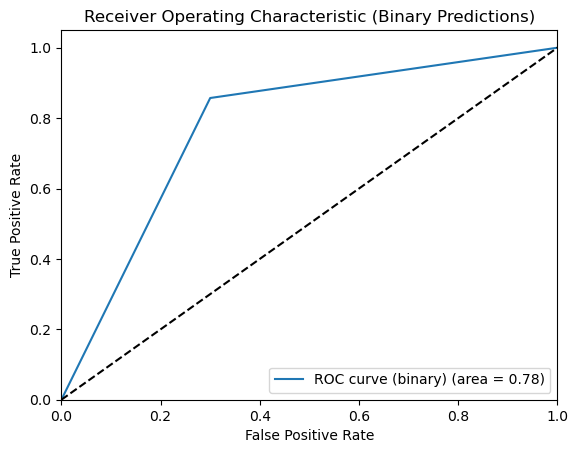

In [34]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Calcular la curva ROC con target_predicted_binary
fpr_binary, tpr_binary, thresholds_binary = roc_curve(test_labels, target_predicted_binary)

# Calcular el área bajo la curva (AUC) para evaluar la calidad de la clasificación con valores binarios
roc_auc_binary = auc(fpr_binary, tpr_binary)

# Crear una nueva figura para el gráfico actualizado
plt.figure()

# Graficar la curva ROC con su AUC utilizando valores binarios
plt.plot(fpr_binary, tpr_binary, label='ROC curve (binary) (area = %0.2f)' % (roc_auc_binary))

# Añadir una línea diagonal punteada que representa un modelo aleatorio
plt.plot([0, 1], [0, 1], 'k--')

# Configurar los límites del eje X y Y
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

# Etiquetas y título del gráfico
plt.xlabel('False Positive Rate')  # Tasa de falsos positivos
plt.ylabel('True Positive Rate')  # Tasa de verdaderos positivos
plt.title('Receiver Operating Characteristic (Binary Predictions)')  # Título del gráfico

# Añadir una leyenda en la esquina inferior derecha
plt.legend(loc="lower right")

# Mostrar el gráfico actualizado
plt.show()


# Conclusión
- El gráfico basado en target_predicted (segunda imagen) es más útil porque muestra cómo se comporta el modelo en distintos escenarios.
- El gráfico basado en target_predicted_binary (primera imagen) es útil solo si estás seguro del umbral que querés usar y no necesitás evaluar otros umbrales.

# Notas de Janu

La elección entre usar target_predicted_binary o target_predicted depende del contexto y de lo que quieras analizar o lograr con tu modelo. Vamos a desglosarlo para que quede claro cuándo usar cada uno.

1. Usar target_predicted (Probabilidades continuas):
Cuándo usarlo:
Cuando querés evaluar el rendimiento general del modelo.
Ejemplo: ¿Cómo se comporta el modelo con distintos niveles de confianza (umbrales)?
Cuando estás explorando y decidiendo el umbral ideal.
Ejemplo: Quiero un umbral que minimice los falsos positivos en un sistema de salud.
Para visualizar la calidad general del modelo con un gráfico ROC.
Ventajas:
Te permite analizar cómo se comportan las tasas de verdaderos positivos (TPR) y falsos positivos (FPR) a través de distintos umbrales.
Ayuda a identificar un umbral óptimo según tus necesidades:
Umbral bajo → Detecta más positivos (alta sensibilidad).
Umbral alto → Reduce falsos positivos (alta especificidad).
El AUC refleja el desempeño general del modelo para toda la gama de umbrales.
Ejemplo:
En un sistema de seguridad bancaria, querés minimizar los casos de fraude no detectados. Primero explorás el comportamiento del modelo con diferentes umbrales para encontrar el balance ideal entre detectar fraudes (TPR) y evitar alarmas falsas (FPR).

2. Usar target_predicted_binary (Predicciones binarias):
Cuándo usarlo:
Cuando ya decidiste un umbral fijo.
Ejemplo: Voy a usar 0.3 como umbral para clasificar entre normal y abnormal.
Cuando querés calcular métricas específicas para un único umbral.
Ejemplo: Sensibilidad, especificidad, precisión, etc., para un caso real con un umbral fijo.
Para evaluar el modelo en un entorno práctico.
Ejemplo: ¿Cómo se comporta el modelo en producción con este umbral fijo?
Ventajas:
Es más simple cuando tenés un umbral fijo, ya que no necesitás explorar otros.
Refleja cómo se desempeña el modelo con el umbral que efectivamente vas a usar.
Útil para tomar decisiones finales o presentar resultados operativos.
Ejemplo:
En un sistema de monitoreo médico, decidiste usar un umbral de 0.3 para clasificar a los pacientes como normales o con anomalías. Ahora evaluás cuántos falsos positivos y negativos hay con ese umbral para validar el desempeño del sistema en ese contexto específico.

Comparación y cuándo usar cada uno
Criterio	target_predicted (ROC Completa)	target_predicted_binary (Umbral fijo)
Exploración inicial	✔ Ideal para entender el modelo globalmente.	✘ Menos útil en esta etapa.
Elección de umbral	✔ Permite comparar distintos umbrales.	✘ No muestra la variación con otros umbrales.
Validación final	✔ Ayuda a justificar el umbral elegido.	✔ Evalúa el modelo con el umbral decidido.
Análisis práctico	✘ Muy detallado para implementaciones.	✔ Refleja cómo funcionará en producción.
Gráfico ROC completo	✔ Ofrece una curva detallada.	✘ Solo un punto en la curva.
¿Cuándo usar uno u otro?
En etapas iniciales del modelo:

Usá target_predicted para explorar y analizar el rendimiento global.
Es clave para decidir un umbral adecuado para el caso de uso.
En etapas finales o producción:

Usá target_predicted_binary cuando ya hayas decidido el umbral.
Esto refleja el rendimiento del modelo con ese umbral en un entorno práctico.
Si necesitás métricas específicas para reportar:

target_predicted_binary es útil para calcular sensibilidad, especificidad, precisión, etc., con un umbral fijo.
Conclusión práctica:
Si estás explorando el modelo y todavía no sabés qué umbral usar: Trabajá con target_predicted.
Si ya sabés qué umbral usar y querés medir su impacto: Trabajá con target_predicted_binary.
